# MCP rough sensitivity v10: clean calibrated histogram-tail sensitivity

This notebook builds a rough expected-yield sensitivity estimate for millicharged particles crossing the detector.

The calculation is split into two pieces:

1. **Production plus geometry**: `A(m)` gives the expected number of MCP crossings per `epsilon^2` for the chosen exposure and detector geometry.
2. **Detector response**: the probability that one MCP track gives at least two above-threshold pixel blips.

The signal estimate used throughout the notebook is:

`N_signal(m, epsilon, T) = A(m) * epsilon^2 * P_track_ge2(epsilon, T)`

The reference detector-response point is fixed to the trusted q2 baseline:

`p_pix(epsilon_ref = 0.01, threshold = 1/3 MIP) = 2.37e-5`

The deposited-energy histogram is used only as a **calibrated shape model** for threshold scaling. The final response model uses the working v6/v9 behavior:

- empirical survival where the histogram is reliable;
- power-law extrapolation only outside the reliable histogram region;
- normalization anchored to the trusted reference point above.

The notebook keeps a few diagnostics before the final sensitivity plot: the production/geometry spline, the deposited-energy histogram, the survival-tail fits, the track-level double-blip probability, and a q2-vs-histogram sanity check.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.interpolate import PchipInterpolator
    from scipy.optimize import curve_fit
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False
    print("scipy not available: using log-log linear interpolation and skipping stretched-exponential fit.")

## 1. Global configuration

In [2]:
# -----------------------------
# Reference charge and signal criterion
# -----------------------------
eps_ref = 0.01
min_signal_events = 3.0

# -----------------------------
# Detector path assumption
# -----------------------------
# Average number of pixels crossed by one MCP track.
# Later this should be replaced by a path-length distribution.
n_pixels_crossed = 300

# -----------------------------
# MIP / threshold convention
# -----------------------------
# Working convention:
#   1 MIP   ~ 0.9 MeV per pixel
#   1/3 MIP ~ 0.3 MeV per pixel
mip_energy_mev = 0.9
threshold_ref_mip_fraction = 1.0 / 3.0
threshold_ref_mev = mip_energy_mev * threshold_ref_mip_fraction

# Trusted reference point from the simple q2_reference/toy-MC baseline.
p_pix_ref_at_threshold_ref = 2.37e-5

# -----------------------------
# Histogram survival-tail fit configuration
# -----------------------------
# We intentionally avoid the very sparse high-energy bins.
tail_fit_min_mev = 0.25
tail_fit_max_mev = 0.60
tail_fit_min_tail_counts = 10
survival_floor = 1e-300

# Actual extrapolation model used after the empirical histogram becomes unreliable.
tail_model_for_sensitivity = "power_law"

# v6 behavior: use empirical survival inside the reliable histogram region,
# and the chosen fit outside that region.
hist_survival_mode = "hybrid"

# Same weighting convention as v6.
# For Poisson tail counts, sigma(log S) ~ 1/sqrt(N_tail), so weight ~ sqrt(N_tail).
tail_fit_weighting = "poisson_log_survival"  # or "uniform"

# -----------------------------
# Plot ranges
# -----------------------------
mass_min_plot = 1e-2
mass_max_plot = 7e-1
eps_min_plot = 1e-4
eps_max_plot = 3e-1

# -----------------------------
# External limit overlays
# -----------------------------
# Change to "MeV" if a limit file stores mass in MeV rather than GeV.
external_limit_mass_unit = "GeV"
extend_external_limits_to_left = False
external_limits = [
    {"filename": "ArgoNeuT  -  2 blip.txt", "label": "ArgoNeuT", "linestyle": "-"},
    {"filename": "LHC.txt", "label": "LHC", "linestyle": "-"},
    {"filename": "MiniBooNE.txt", "label": "MiniBooNE", "linestyle": "-"},
    {"filename": "MilliQ at SLAC.txt", "label": "MilliQ at SLAC", "linestyle": "-"},
]

## 2. Production + geometry acceptance table

The table is interpreted as `N_cross(m, epsilon) = A(m) * epsilon^2`.

So `acc_over_eps2_base` should already include the chosen POT/exposure normalization and detector crossing geometry.

In [3]:
mass_data = np.array([
    0.01, 0.012589, 0.015849, 0.019953, 0.025119, 0.031623,
    0.039811, 0.050119, 0.063096, 0.079433, 0.1, 0.125893,
    0.158489, 0.199526, 0.251189, 0.316228, 0.398107, 0.501187
], dtype=float)

# Working v6 acceptance table. Keep this synchronized with the production/geometry input
# used for the validated v6 comparison.
acc_over_eps2_base = np.array([
    1.07E14, 9.86E13, 9.74E13, 9.00E13, 7.73E13, 6.15E13,
    3.69E13, 1.53E13, 4.80E12, 4.09E12, 3.95E12, 3.36E12,
    2.33E12, 9.71E11, 6.87E10, 1.18E10, 2.16E09, 5.83E07
], dtype=float)

assert len(mass_data) == len(acc_over_eps2_base)
assert np.all(np.diff(mass_data) > 0)
assert np.all(acc_over_eps2_base > 0)


def build_loglog_interpolator(x, y):
    """Shape-preserving interpolation in log10(x), log10(y)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    lx = np.log10(x)
    ly = np.log10(y)

    if HAVE_SCIPY:
        pchip = PchipInterpolator(lx, ly)
        def interp(x_new):
            return 10 ** pchip(np.log10(np.asarray(x_new, dtype=float)))
        return interp

    def interp(x_new):
        return 10 ** np.interp(np.log10(np.asarray(x_new, dtype=float)), lx, ly)
    return interp


acc_interp_base = build_loglog_interpolator(mass_data, acc_over_eps2_base)

## 3. Production and geometry spline check

This plot shows the input `A(m)` table and the log-log interpolation used by the sensitivity scan. It is meant as a quick visual check that the mass dependence is smooth and that the interpolation is not creating artificial bumps or fake sensitivity improvements.

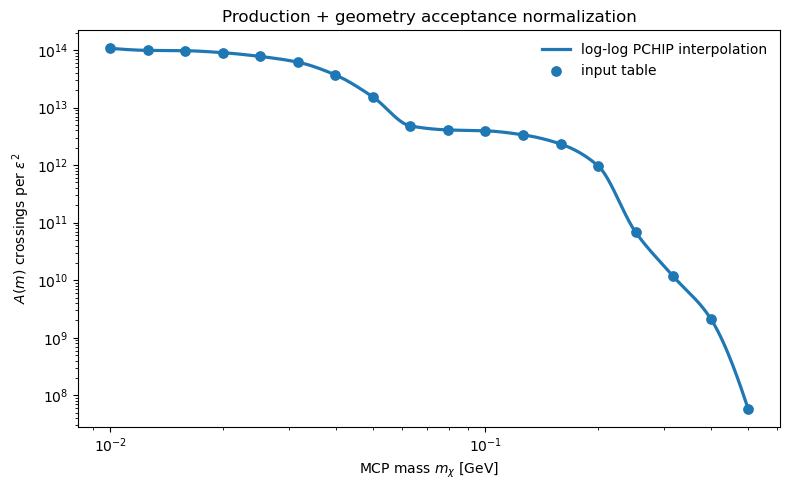

m =  0.01000 GeV   A(m) = 1.0700e+14 crossings / epsilon^2
m =  0.01259 GeV   A(m) = 9.8600e+13 crossings / epsilon^2
m =  0.01585 GeV   A(m) = 9.7400e+13 crossings / epsilon^2
m =  0.01995 GeV   A(m) = 9.0000e+13 crossings / epsilon^2
m =  0.02512 GeV   A(m) = 7.7300e+13 crossings / epsilon^2
m =  0.03162 GeV   A(m) = 6.1500e+13 crossings / epsilon^2
m =  0.03981 GeV   A(m) = 3.6900e+13 crossings / epsilon^2
m =  0.05012 GeV   A(m) = 1.5300e+13 crossings / epsilon^2
m =  0.06310 GeV   A(m) = 4.8000e+12 crossings / epsilon^2
m =  0.07943 GeV   A(m) = 4.0900e+12 crossings / epsilon^2
m =  0.10000 GeV   A(m) = 3.9500e+12 crossings / epsilon^2
m =  0.12589 GeV   A(m) = 3.3600e+12 crossings / epsilon^2
m =  0.15849 GeV   A(m) = 2.3300e+12 crossings / epsilon^2
m =  0.19953 GeV   A(m) = 9.7100e+11 crossings / epsilon^2
m =  0.25119 GeV   A(m) = 6.8700e+10 crossings / epsilon^2
m =  0.31623 GeV   A(m) = 1.1800e+10 crossings / epsilon^2
m =  0.39811 GeV   A(m) = 2.1600e+09 crossings / epsilon

In [4]:
mass_grid_acceptance = np.logspace(np.log10(mass_data.min()), np.log10(mass_data.max()), 600)
acc_grid_acceptance = acc_interp_base(mass_grid_acceptance)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xscale("log")
ax.set_yscale("log")
ax.plot(mass_grid_acceptance, acc_grid_acceptance, linewidth=2.3, label="log-log PCHIP interpolation")
ax.scatter(mass_data, acc_over_eps2_base, s=45, zorder=3, label="input table")
ax.set_xlabel(r"MCP mass $m_\chi$ [GeV]")
ax.set_ylabel(r"$A(m)$ crossings per $\epsilon^2$")
ax.set_title("Production + geometry acceptance normalization")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# Optional numerical view of the input table.
for m, a in zip(mass_data, acc_over_eps2_base):
    print(f"m = {m:8.5f} GeV   A(m) = {a:.4e} crossings / epsilon^2")

## 4. Deposited-energy histogram input

The histogram should be the reference-charge deposited-energy spectrum at `eps_ref = 0.01`.

Expected file format:

```text
# edep_mev   counts
0.007   123
0.010   456
...
```

The calibrated model only uses survival-function ratios, so the absolute denominator is not used for the final sensitivity. The diagnostic denominator is kept only to display raw survival probabilities.

In [5]:
# Path to deposited-energy histogram at eps_ref.
# The first filename is the repo-clean name; the second helps if the browser appends " (2)" during upload/download.
edep_histogram_candidates = [
    Path("mcp_edep_histogram_eps0p01.txt"),
    Path("mcp_edep_histogram_eps0p01 (2).txt"),
]
edep_histogram_file = next((p for p in edep_histogram_candidates if p.exists()), edep_histogram_candidates[0])

# Optional: paste arrays directly here. If both arrays are set, they take precedence over the file.
edep_hist_mev = None
edep_hist_counts = None

# Diagnostic denominator only. For the current toy MC this was approximately:
histogram_total_opportunities = 1_000_000 * 300
# histogram_total_opportunities = None  # Use counts.sum() instead.


def histogram_available():
    if edep_hist_mev is not None and edep_hist_counts is not None:
        return True
    return edep_histogram_file is not None and Path(edep_histogram_file).exists()


def load_edep_histogram():
    """Return sorted deposited-energy bin centers and counts."""
    if edep_hist_mev is not None and edep_hist_counts is not None:
        edep = np.asarray(edep_hist_mev, dtype=float)
        counts = np.asarray(edep_hist_counts, dtype=float)
    elif edep_histogram_file is not None and Path(edep_histogram_file).exists():
        data = np.loadtxt(edep_histogram_file, comments="#")
        if data.ndim == 1:
            data = data.reshape(1, -1)
        edep = data[:, 0].astype(float)
        counts = data[:, 1].astype(float)
    else:
        raise FileNotFoundError(
            f"Could not find deposited-energy histogram: {edep_histogram_file!s}. "
            "Place it next to the notebook or paste arrays into edep_hist_mev/edep_hist_counts."
        )

    ok = np.isfinite(edep) & np.isfinite(counts) & (counts >= 0)
    edep = edep[ok]
    counts = counts[ok]
    order = np.argsort(edep)
    return edep[order], counts[order]


def get_histogram_denominator(counts):
    if histogram_total_opportunities is None:
        return float(np.sum(counts))
    return float(histogram_total_opportunities)

## 5. Deposited-energy histogram

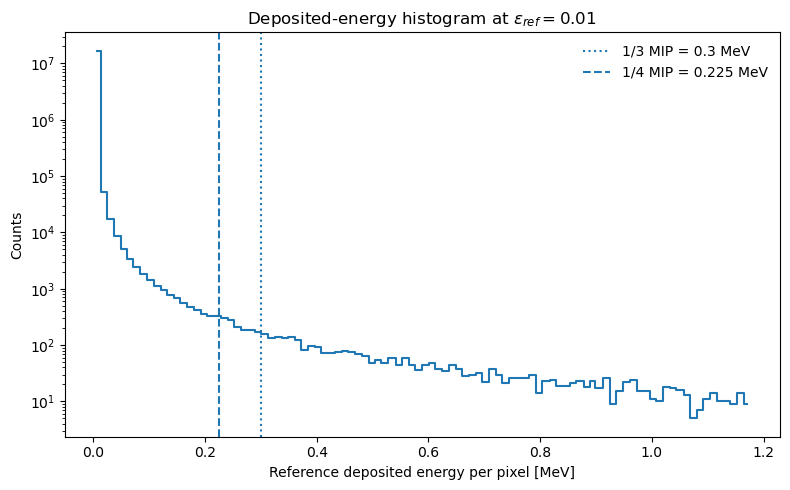

In [6]:
if histogram_available():
    edep, counts = load_edep_histogram()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_yscale("log")
    ax.step(edep, counts, where="mid")
    ax.axvline(threshold_ref_mev, linestyle=":", label=f"1/3 MIP = {threshold_ref_mev:.3g} MeV")
    ax.axvline(mip_energy_mev / 4.0, linestyle="--", label=f"1/4 MIP = {mip_energy_mev/4:.3g} MeV")
    ax.set_xlabel("Reference deposited energy per pixel [MeV]")
    ax.set_ylabel("Counts")
    ax.set_title(rf"Deposited-energy histogram at $\epsilon_{{ref}}={eps_ref:g}$")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("No deposited-energy histogram found yet; this plot will run once the histogram file/arrays are provided.")

## 6. Survival tail and three fit shapes

This cell shows the empirical survival function and three possible extrapolation models. The sparse high-energy region above the configured fit window is not used to determine the fit.

For the final sensitivity curves, the notebook uses the v6 behavior: **empirical survival where reliable, then power-law extrapolation outside the reliable region**.

exponential_E: logS = -10.31 + (-3.853) E, decay length = 0.2595 MeV
power_law: logS = -13.29 + (-1.517) log(E), beta = 1.517
stretched_exponential: logA = -8.804, E0 = 0.04259 MeV, gamma = 0.5014

Sensitivity survival mode: 'hybrid'
Sensitivity extrapolation model: 'power_law'
Fit window: 0.25 to 0.6 MeV


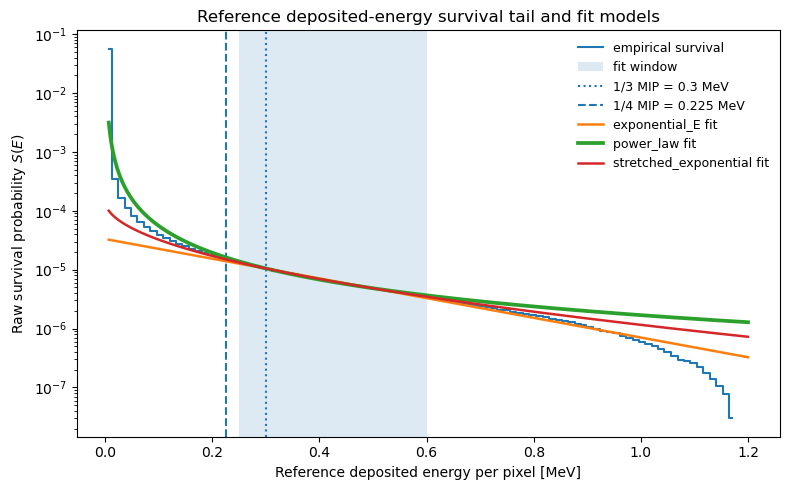

In [7]:
def get_reference_survival_table():
    """
    Return edep, counts, tail_counts, and raw survival probability.

    tail_counts[i] = sum counts[j] for edep[j] >= edep[i].
    """
    edep, counts = load_edep_histogram()
    denom = get_histogram_denominator(counts)
    tail_counts = np.cumsum(counts[::-1])[::-1]
    survival = tail_counts / denom
    return edep, counts, tail_counts, survival


def empirical_tail_counts_at(thresholds_mev):
    """Step-function tail counts: sum counts for edep >= threshold."""
    edep, counts = load_edep_histogram()
    tail_counts = np.cumsum(counts[::-1])[::-1]

    thresholds = np.asarray(thresholds_mev, dtype=float)
    idx = np.searchsorted(edep, thresholds, side="left")

    out = np.zeros_like(thresholds, dtype=float)
    in_range = idx < len(edep)
    out[in_range] = tail_counts[idx[in_range]]
    return out


def empirical_survival_at(thresholds_mev):
    edep, counts = load_edep_histogram()
    denom = get_histogram_denominator(counts)
    return empirical_tail_counts_at(thresholds_mev) / denom


def tail_fit_mask(edep, tail_counts, survival):
    return (
        (edep >= tail_fit_min_mev)
        & (edep <= tail_fit_max_mev)
        & (tail_counts >= tail_fit_min_tail_counts)
        & (survival > 0)
        & np.isfinite(edep)
        & np.isfinite(survival)
    )


def _polyfit_with_optional_weights(x, y, tail_counts):
    if tail_fit_weighting == "poisson_log_survival":
        w = np.sqrt(np.maximum(tail_counts, 1.0))
        return np.polyfit(x, y, deg=1, w=w)
    if tail_fit_weighting == "uniform":
        return np.polyfit(x, y, deg=1)
    raise ValueError(f"Unknown tail_fit_weighting: {tail_fit_weighting}")


def fit_exponential_E(edep, survival, tail_counts):
    """Fit log S(E) = a + b E."""
    y = np.log(np.clip(survival, survival_floor, None))
    b, a = _polyfit_with_optional_weights(edep, y, tail_counts)
    return {"model": "exponential_E", "a": float(a), "b": float(b)}


def fit_power_law(edep, survival, tail_counts):
    """Fit log S(E) = a + b log(E)."""
    x = np.log(edep)
    y = np.log(np.clip(survival, survival_floor, None))
    b, a = _polyfit_with_optional_weights(x, y, tail_counts)
    return {"model": "power_law", "a": float(a), "b": float(b), "beta": float(-b)}


def fit_stretched_exponential(edep, survival, tail_counts):
    """Fit log S(E) = logA - (E/E0)^gamma."""
    if not HAVE_SCIPY:
        raise RuntimeError("scipy is required for stretched-exponential fit")

    y = np.log(np.clip(survival, survival_floor, None))

    def model(E, logA, logE0, gamma):
        E0 = np.exp(logE0)
        return logA - (E / E0) ** gamma

    # Safe initial guesses.
    logA0 = float(np.max(y))
    logE00 = np.log(max(np.median(edep), 1e-3))
    gamma0 = 0.5

    sigma = None
    if tail_fit_weighting == "poisson_log_survival":
        sigma = 1.0 / np.sqrt(np.maximum(tail_counts, 1.0))

    popt, pcov = curve_fit(
        model,
        edep,
        y,
        p0=[logA0, logE00, gamma0],
        sigma=sigma,
        absolute_sigma=False,
        bounds=([-np.inf, np.log(1e-4), 0.05], [np.inf, np.log(100.0), 5.0]),
        maxfev=20000,
    )
    return {"model": "stretched_exponential", "logA": float(popt[0]), "logE0": float(popt[1]), "gamma": float(popt[2])}


def eval_survival_fit(E, fit):
    E = np.asarray(E, dtype=float)
    E_safe = np.clip(E, 1e-12, None)
    model = fit["model"]

    if model == "exponential_E":
        logS = fit["a"] + fit["b"] * E_safe
    elif model == "power_law":
        logS = fit["a"] + fit["b"] * np.log(E_safe)
    elif model == "stretched_exponential":
        E0 = np.exp(fit["logE0"])
        logS = fit["logA"] - (E_safe / E0) ** fit["gamma"]
    else:
        raise ValueError(f"Unknown fit model: {model}")

    return np.clip(np.exp(np.clip(logS, np.log(survival_floor), 0.0)), survival_floor, 1.0)


def survival_model_at(thresholds_mev, fit, mode=None):
    """Return raw survival probability in empirical, fit, or hybrid mode."""
    if mode is None:
        mode = hist_survival_mode

    thresholds = np.asarray(thresholds_mev, dtype=float)

    if mode == "fit":
        return eval_survival_fit(thresholds, fit)

    empirical = empirical_survival_at(thresholds)
    empirical_counts = empirical_tail_counts_at(thresholds)

    if mode == "empirical":
        out = empirical

    elif mode == "hybrid":
        # v6 behavior: use empirical only where it is statistically useful and inside
        # the trusted histogram range; otherwise use the fitted power-law tail.
        reliable_empirical = (
            (thresholds <= tail_fit_max_mev)
            & (empirical_counts >= tail_fit_min_tail_counts)
            & (empirical > 0)
        )
        fitted = eval_survival_fit(thresholds, fit)
        out = np.where(reliable_empirical, empirical, fitted)

    else:
        raise ValueError(f"Unknown hist_survival_mode: {mode}")

    return np.clip(out, survival_floor, 1.0)


def describe_fit(fit):
    if fit["model"] == "exponential_E":
        decay_length = -1.0 / fit["b"] if fit["b"] < 0 else np.inf
        return f"exponential_E: logS = {fit['a']:.4g} + ({fit['b']:.4g}) E, decay length = {decay_length:.4g} MeV"
    if fit["model"] == "power_law":
        return f"power_law: logS = {fit['a']:.4g} + ({fit['b']:.4g}) log(E), beta = {fit['beta']:.4g}"
    if fit["model"] == "stretched_exponential":
        return f"stretched_exponential: logA = {fit['logA']:.4g}, E0 = {np.exp(fit['logE0']):.4g} MeV, gamma = {fit['gamma']:.4g}"
    return str(fit)


if histogram_available():
    edep, counts, tail_counts, survival = get_reference_survival_table()
    mask = tail_fit_mask(edep, tail_counts, survival)

    if np.count_nonzero(mask) < 3:
        raise RuntimeError("Too few points in the survival-tail fit window. Adjust tail_fit_min_mev/tail_fit_max_mev/tail_fit_min_tail_counts.")

    tail_fits = {
        "exponential_E": fit_exponential_E(edep[mask], survival[mask], tail_counts[mask]),
        "power_law": fit_power_law(edep[mask], survival[mask], tail_counts[mask]),
    }
    if HAVE_SCIPY:
        tail_fits["stretched_exponential"] = fit_stretched_exponential(edep[mask], survival[mask], tail_counts[mask])

    for fit in tail_fits.values():
        print(describe_fit(fit))

    if tail_model_for_sensitivity not in tail_fits:
        raise RuntimeError(f"Requested tail_model_for_sensitivity={tail_model_for_sensitivity!r} was not fit.")

    print(f"\nSensitivity survival mode: {hist_survival_mode!r}")
    print(f"Sensitivity extrapolation model: {tail_model_for_sensitivity!r}")
    print(f"Fit window: {tail_fit_min_mev:g} to {tail_fit_max_mev:g} MeV")

    xfit = np.linspace(max(1e-4, np.min(edep[edep > 0])), max(1.2, edep.max()), 1000)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_yscale("log")
    ax.step(edep, survival, where="mid", label="empirical survival")
    ax.axvspan(tail_fit_min_mev, tail_fit_max_mev, alpha=0.15, label="fit window")
    ax.axvline(threshold_ref_mev, linestyle=":", label=f"1/3 MIP = {threshold_ref_mev:.3g} MeV")
    ax.axvline(mip_energy_mev / 4.0, linestyle="--", label=f"1/4 MIP = {mip_energy_mev/4:.3g} MeV")

    for name, fit in tail_fits.items():
        lw = 2.7 if name == tail_model_for_sensitivity else 1.8
        ax.plot(xfit, eval_survival_fit(xfit, fit), label=f"{name} fit", lw=lw)

    ax.set_xlabel("Reference deposited energy per pixel [MeV]")
    ax.set_ylabel(r"Raw survival probability $S(E)$")
    ax.set_title("Reference deposited-energy survival tail and fit models")
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    tail_fits = {}
    print("No deposited-energy histogram found yet; fit comparison will run once the histogram file/arrays are provided.")

## 7. Detector response and track-level double-blip probability

In [8]:
def threshold_mev(threshold_mip_fraction):
    return mip_energy_mev * threshold_mip_fraction


def threshold_label(threshold_mip_fraction):
    inv = 1.0 / threshold_mip_fraction
    if abs(inv - round(inv)) < 1e-8:
        return f"1/{int(round(inv))} MIP"
    return f"{threshold_mip_fraction:.3g} MIP"


def p_pix_q2_reference(eps):
    """Trusted fixed-threshold baseline. Used only for comparison/checks if desired."""
    eps = np.asarray(eps, dtype=float)
    return np.clip(p_pix_ref_at_threshold_ref * (eps / eps_ref) ** 2, 0.0, 1.0)


def p_pix_histogram_tail_calibrated_power_law(eps, threshold_mip_fraction):
    """
    Calibrated histogram-tail response using the v6 hybrid behavior.

    p_pix(eps, T) = p_pix_ref * S(T * (eps_ref/eps)^2) / S(T_ref),
    where S is empirical inside the reliable histogram region and the power-law
    fit outside it.
    """
    if not histogram_available():
        raise RuntimeError("Histogram is required for calibrated histogram-tail response.")
    if tail_model_for_sensitivity not in tail_fits:
        raise RuntimeError(f"Requested tail model {tail_model_for_sensitivity!r} was not fit.")

    fit = tail_fits[tail_model_for_sensitivity]
    eps = np.asarray(eps, dtype=float)
    eps_safe = np.clip(eps, 1e-300, None)
    equiv_threshold_ref_mev = threshold_mev(threshold_mip_fraction) * (eps_ref / eps_safe) ** 2

    s_target = survival_model_at(equiv_threshold_ref_mev, fit=fit, mode=hist_survival_mode)
    s_ref = float(survival_model_at(np.array([threshold_ref_mev]), fit=fit, mode=hist_survival_mode)[0])

    if not np.isfinite(s_ref) or s_ref <= 0:
        raise RuntimeError("Reference survival is zero or invalid. Cannot calibrate histogram-tail model.")

    p = p_pix_ref_at_threshold_ref * (s_target / s_ref)
    return np.clip(p, 0.0, 1.0)


def p_track_ge2_from_ppix(p_pix, n_pixels=n_pixels_crossed):
    """Probability of at least two above-threshold pixels along one MCP track."""
    p = np.clip(np.asarray(p_pix, dtype=float), 0.0, 1.0)
    return 1.0 - (1.0 - p) ** n_pixels - n_pixels * p * (1.0 - p) ** (n_pixels - 1)


def p_track_ge2_q2_reference(eps):
    """Track-level double-blip probability for the fixed-threshold q2 baseline."""
    return p_track_ge2_from_ppix(p_pix_q2_reference(eps))


def p_track_ge2_hist_cal_power_law(eps, threshold_mip_fraction):
    """Track-level double-blip probability for the calibrated hybrid power-law histogram-tail model."""
    p_pix = p_pix_histogram_tail_calibrated_power_law(eps, threshold_mip_fraction)
    return p_track_ge2_from_ppix(p_pix)


def p_track_ge2(eps, threshold_mip_fraction, response_model="hist_cal_power_law"):
    """
    Dispatch track probability by response model.

    response_model:
      - "hist_cal_power_law": calibrated histogram-tail model, with threshold scaling.
      - "q2_reference": fixed-threshold baseline, ignores threshold_mip_fraction.
    """
    if response_model == "hist_cal_power_law":
        return p_track_ge2_hist_cal_power_law(eps, threshold_mip_fraction)
    if response_model == "q2_reference":
        return p_track_ge2_q2_reference(eps)
    raise ValueError(f"Unknown response_model: {response_model!r}")


if histogram_available():
    # Calibration sanity check.
    cal_ref = float(p_pix_histogram_tail_calibrated_power_law(np.array([eps_ref]), threshold_ref_mip_fraction)[0])
    q2_ref = float(p_pix_q2_reference(np.array([eps_ref]))[0])
    ptr_hist_ref = float(p_track_ge2_hist_cal_power_law(np.array([eps_ref]), threshold_ref_mip_fraction)[0])
    ptr_q2_ref = float(p_track_ge2_q2_reference(np.array([eps_ref]))[0])

    print(f"trusted p_pix_ref                         = {p_pix_ref_at_threshold_ref:.6e}")
    print(f"q2 p_pix(eps_ref)                         = {q2_ref:.6e}")
    print(f"hybrid calibrated p_pix(eps_ref, 1/3)     = {cal_ref:.6e}")
    print(f"relative p_pix error hist/q2              = {cal_ref / q2_ref - 1:+.3e}")
    print(f"q2 P_track>=2(eps_ref)                    = {ptr_q2_ref:.6e}")
    print(f"hist-cal P_track>=2(eps_ref, 1/3)         = {ptr_hist_ref:.6e}")
    print(f"relative P_track error hist/q2            = {ptr_hist_ref / ptr_q2_ref - 1:+.3e}")

    assert np.isclose(cal_ref, q2_ref, rtol=1e-12, atol=0.0)
    assert np.isclose(ptr_hist_ref, ptr_q2_ref, rtol=1e-12, atol=0.0)

    cal_quarter = float(p_pix_histogram_tail_calibrated_power_law(np.array([eps_ref]), 1/4)[0])
    print(f"hybrid calibrated p_pix(eps_ref, 1/4)     = {cal_quarter:.6e}")
    print(f"1/4 over 1/3 threshold gain               = {cal_quarter / cal_ref:.6g}")
else:
    print("No deposited-energy histogram found yet; detector-response calibration check is skipped.")


trusted p_pix_ref                         = 2.370000e-05
q2 p_pix(eps_ref)                         = 2.370000e-05
hybrid calibrated p_pix(eps_ref, 1/3)     = 2.370000e-05
relative p_pix error hist/q2              = +0.000e+00
q2 P_track>=2(eps_ref)                    = 2.507350e-05
hist-cal P_track>=2(eps_ref, 1/3)         = 2.507350e-05
relative P_track error hist/q2            = +0.000e+00
hybrid calibrated p_pix(eps_ref, 1/4)     = 3.396122e-05
1/4 over 1/3 threshold gain               = 1.43296


## 8. Four sensitivity scenarios

In [9]:
scenarios = [
    {
        "label": "1/3 MIP, current exposure",
        "threshold_mip_fraction": 1.0 / 3.0,
        "exposure_scale": 1.0,
        "linestyle": "-",
    },
    {
        "label": "1/3 MIP, 20x exposure",
        "threshold_mip_fraction": 1.0 / 3.0,
        "exposure_scale": 20.0,
        "linestyle": "--",
    },
    {
        "label": "1/4 MIP, current exposure",
        "threshold_mip_fraction": 1.0 / 4.0,
        "exposure_scale": 1.0,
        "linestyle": "-.",
    },
    {
        "label": "1/4 MIP, 20x exposure",
        "threshold_mip_fraction": 1.0 / 4.0,
        "exposure_scale": 20.0,
        "linestyle": ":",
    },
]

## 9. Track-level double-blip probability

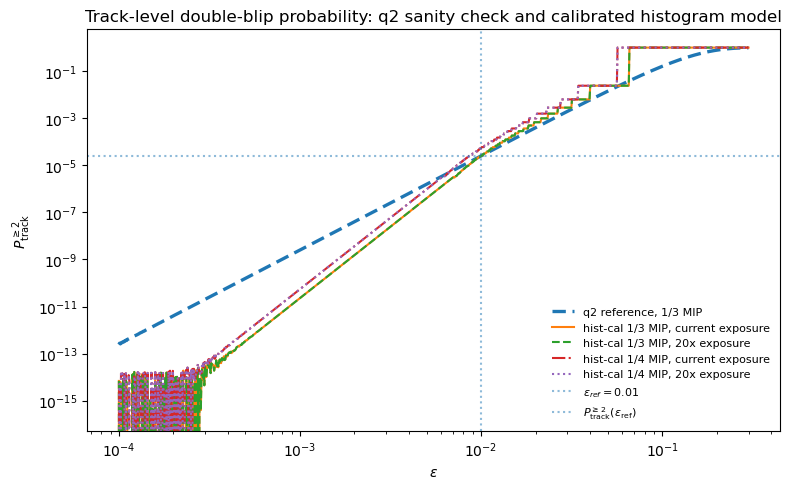

In [10]:
eps_test = np.logspace(np.log10(eps_min_plot), np.log10(eps_max_plot), 900)

if histogram_available():
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Explicit q2 reference curve: this must cross the calibrated 1/3-MIP curve at eps_ref.
    ax.plot(
        eps_test,
        p_track_ge2_q2_reference(eps_test),
        linewidth=2.4,
        linestyle=(0, (4, 2)),
        label="q2 reference, 1/3 MIP",
    )

    for sc in scenarios:
        probs = p_track_ge2_hist_cal_power_law(eps_test, sc["threshold_mip_fraction"])
        ax.plot(eps_test, probs, linestyle=sc["linestyle"], label=f"hist-cal {sc['label']}")

    ax.axvline(eps_ref, linestyle=":", alpha=0.5, label=rf"$\epsilon_{{ref}}={eps_ref:g}$")
    ax.axhline(
        float(p_track_ge2_q2_reference(np.array([eps_ref]))[0]),
        linestyle=":",
        alpha=0.5,
        label=r"$P_{\rm track}^{\geq2}(\epsilon_{\rm ref})$",
    )
    ax.set_xlabel(r"$\epsilon$")
    ax.set_ylabel(r"$P_{\rm track}^{\geq2}$")
    ax.set_title("Track-level double-blip probability: q2 sanity check and calibrated histogram model")
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No deposited-energy histogram found yet; track-probability plot will run once the histogram file/arrays are provided.")


## 10. Sensitivity contours

In [11]:
def n_crossings(mass, eps, exposure_scale=1.0):
    return exposure_scale * acc_interp_base(mass) * eps**2


def n_signal(mass, eps, scenario):
    response_model = scenario.get("response_model", "hist_cal_power_law")
    return (
        n_crossings(mass, eps, scenario["exposure_scale"])
        * p_track_ge2(eps, scenario["threshold_mip_fraction"], response_model=response_model)
    )


def find_contour(
    scenario,
    min_events=min_signal_events,
    mmin=mass_min_plot,
    mmax=mass_max_plot,
    epsmin=eps_min_plot,
    epsmax=eps_max_plot,
    nm=600,
    neps=3000,
):
    masses = np.logspace(np.log10(mmin), np.log10(mmax), nm)
    masses = masses[(masses >= mass_data.min()) & (masses <= mass_data.max())]
    eps_scan = np.logspace(np.log10(epsmin), np.log10(epsmax), neps)

    out_m = []
    out_eps = []

    for m in masses:
        vals = n_signal(m, eps_scan, scenario)
        passing = np.where(vals >= min_events)[0]
        if passing.size:
            out_m.append(m)
            out_eps.append(eps_scan[passing[0]])

    return np.array(out_m), np.array(out_eps)


def load_external_limit(filename):
    pts = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) < 2:
                continue
            pts.append((float(parts[0]), float(parts[1])))

    arr = np.asarray(pts, dtype=float)
    if arr.size == 0:
        return np.array([]), np.array([])

    mass = arr[:, 0]
    eps = arr[:, 1]
    if external_limit_mass_unit.lower() == "mev":
        mass = mass / 1000.0
    elif external_limit_mass_unit.lower() != "gev":
        raise ValueError("external_limit_mass_unit must be 'GeV' or 'MeV'")
    return mass, eps


def draw_external_limits(ax):
    for item in external_limits:
        filename = item["filename"]
        if not Path(filename).exists():
            print(f"External limit file not found, skipping: {filename}")
            continue
        x, y = load_external_limit(filename)
        if len(x) < 2:
            print(f"External limit file has too few points, skipping: {filename}")
            continue

        ax.fill_between(x, y, eps_max_plot, alpha=0.12)
        ax.plot(
            x,
            y,
            linestyle=item.get("linestyle", "--"),
            linewidth=item.get("linewidth", 2.2),
            label=item.get("label", Path(filename).stem),
        )

        if extend_external_limits_to_left and x[0] > mass_min_plot:
            ax.fill_between([mass_min_plot, x[0]], [y[0], y[0]], eps_max_plot, alpha=0.08)

## 11. q2 vs calibrated histogram sanity check

At the reference charge and reference threshold, the q2 model and calibrated histogram-tail model should agree exactly. The contours should therefore cross at the same mass where the required charge is \(\epsilon_{ref}\), for the same exposure.


Exposure scale = 1
  max relative Nsig difference at eps_ref = 0.000e+00
  q2 contour mass at eps_ref              = 0.418861 GeV
  hist-cal contour mass at eps_ref        = 0.418683 GeV
  relative contour-crossing difference    = -4.258e-04

Exposure scale = 20
  max relative Nsig difference at eps_ref = 0.000e+00
  contour does not cross eps_ref inside the plotted mass/epsilon range
  this is still fine; the direct Nsig-at-eps_ref check above is the stricter test


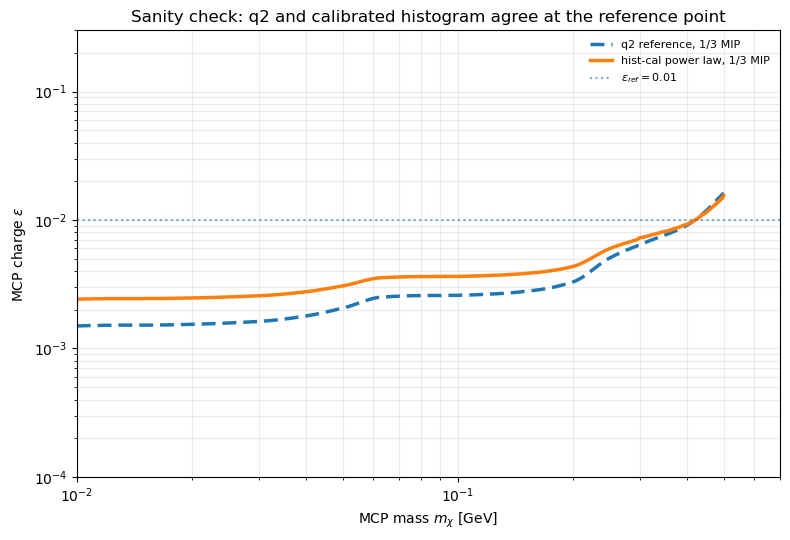

In [12]:
def mass_at_epsilon_on_contour(m_contour, eps_contour, eps_value=eps_ref):
    """Log-log interpolate contour mass at a chosen epsilon."""
    m = np.asarray(m_contour, dtype=float)
    e = np.asarray(eps_contour, dtype=float)
    ok = np.isfinite(m) & np.isfinite(e) & (m > 0) & (e > 0)
    m = m[ok]
    e = e[ok]
    if len(m) < 2 or eps_value < e.min() or eps_value > e.max():
        return np.nan
    order = np.argsort(e)
    return float(np.exp(np.interp(np.log(eps_value), np.log(e[order]), np.log(m[order]))))


if histogram_available():
    masses_check = np.logspace(np.log10(mass_data.min()), np.log10(mass_data.max()), 500)

    for exposure_scale in [1.0, 20.0]:
        sc_q2 = {
            "label": f"q2 reference, 1/3 MIP, {exposure_scale:g}x exposure",
            "threshold_mip_fraction": threshold_ref_mip_fraction,
            "exposure_scale": exposure_scale,
            "response_model": "q2_reference",
        }
        sc_hist = {
            "label": f"hist-cal power law, 1/3 MIP, {exposure_scale:g}x exposure",
            "threshold_mip_fraction": threshold_ref_mip_fraction,
            "exposure_scale": exposure_scale,
            "response_model": "hist_cal_power_law",
        }

        n_q2 = n_signal(masses_check, eps_ref, sc_q2)
        n_hist = n_signal(masses_check, eps_ref, sc_hist)
        max_rel = np.max(np.abs(n_hist - n_q2) / np.maximum(np.abs(n_q2), 1e-300))

        m_q2, e_q2 = find_contour(sc_q2, neps=10000)
        m_hist, e_hist = find_contour(sc_hist, neps=10000)
        m_q2_at_ref = mass_at_epsilon_on_contour(m_q2, e_q2, eps_ref)
        m_hist_at_ref = mass_at_epsilon_on_contour(m_hist, e_hist, eps_ref)

        print(f"\nExposure scale = {exposure_scale:g}")
        print(f"  max relative Nsig difference at eps_ref = {max_rel:.3e}")
        if np.isfinite(m_q2_at_ref) and np.isfinite(m_hist_at_ref):
            print(f"  q2 contour mass at eps_ref              = {m_q2_at_ref:.6g} GeV")
            print(f"  hist-cal contour mass at eps_ref        = {m_hist_at_ref:.6g} GeV")
            print(f"  relative contour-crossing difference    = {m_hist_at_ref / m_q2_at_ref - 1:+.3e}")
        else:
            print("  contour does not cross eps_ref inside the plotted mass/epsilon range")
            print("  this is still fine; the direct Nsig-at-eps_ref check above is the stricter test")

    # Compact diagnostic plot around the reference point.
    sc_q2_current = {
        "label": "q2 reference, 1/3 MIP, current exposure",
        "threshold_mip_fraction": threshold_ref_mip_fraction,
        "exposure_scale": 1.0,
        "response_model": "q2_reference",
    }
    sc_hist_current = {
        "label": "hist-cal power law, 1/3 MIP, current exposure",
        "threshold_mip_fraction": threshold_ref_mip_fraction,
        "exposure_scale": 1.0,
        "response_model": "hist_cal_power_law",
    }

    m_q2, e_q2 = find_contour(sc_q2_current)
    m_hist, e_hist = find_contour(sc_hist_current)

    fig, ax = plt.subplots(figsize=(8, 5.5))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.plot(m_q2, e_q2, linewidth=2.5, linestyle=(0, (4, 2)), label="q2 reference, 1/3 MIP")
    ax.plot(m_hist, e_hist, linewidth=2.5, linestyle="-", label="hist-cal power law, 1/3 MIP")
    ax.axhline(eps_ref, linestyle=":", alpha=0.6, label=rf"$\epsilon_{{ref}}={eps_ref:g}$")
    ax.set_xlim(mass_min_plot, mass_max_plot)
    ax.set_ylim(eps_min_plot, eps_max_plot)
    ax.set_xlabel(r"MCP mass $m_\chi$ [GeV]")
    ax.set_ylabel(r"MCP charge $\epsilon$")
    ax.set_title("Sanity check: q2 and calibrated histogram agree at the reference point")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No deposited-energy histogram found yet; q2/hist-cal sanity check is skipped.")


1/3 MIP, current exposure: epsilon range 2.417e-03 -- 1.545e-02
1/3 MIP, 20x exposure: epsilon range 1.667e-03 -- 9.920e-03
1/4 MIP, current exposure: epsilon range 2.172e-03 -- 1.400e-02
1/4 MIP, 20x exposure: epsilon range 1.499e-03 -- 8.940e-03


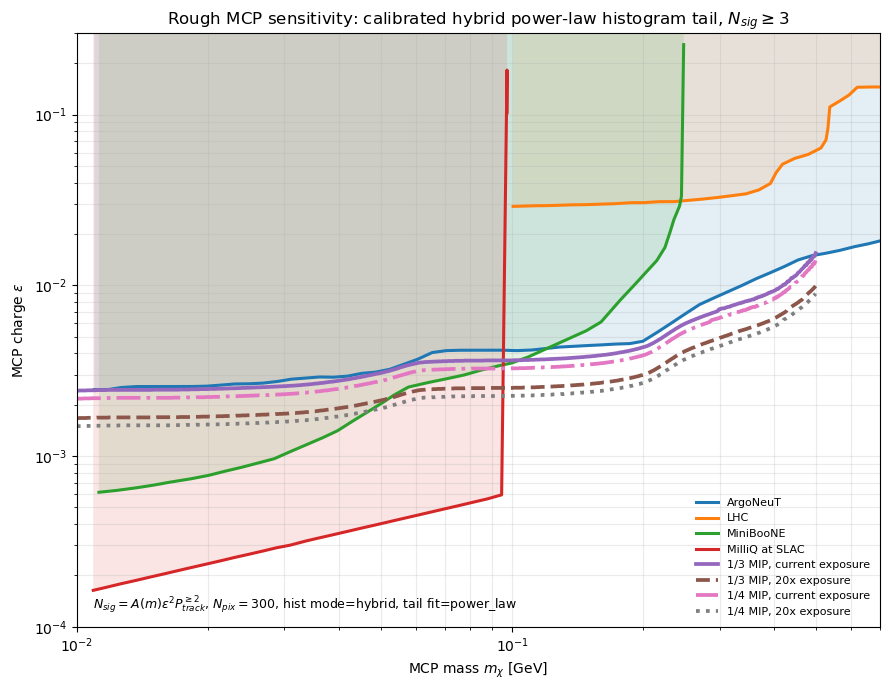

In [13]:
if histogram_available():
    contours = []
    for sc in scenarios:
        m_contour, eps_contour = find_contour(sc)
        contours.append((sc, m_contour, eps_contour))
        if len(m_contour):
            print(f"{sc['label']}: epsilon range {eps_contour.min():.3e} -- {eps_contour.max():.3e}")
        else:
            print(f"{sc['label']}: no contour found in scan range")

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(mass_min_plot, mass_max_plot)
    ax.set_ylim(eps_min_plot, eps_max_plot)

    draw_external_limits(ax)

    for sc, m_contour, eps_contour in contours:
        if len(m_contour) == 0:
            continue
        ax.plot(m_contour, eps_contour, linestyle=sc["linestyle"], linewidth=2.7, label=sc["label"])

    ax.set_xlabel(r"MCP mass $m_\chi$ [GeV]")
    ax.set_ylabel(r"MCP charge $\epsilon$")
    ax.set_title(rf"Rough MCP sensitivity: calibrated hybrid power-law histogram tail, $N_{{sig}}\geq {min_signal_events:g}$")
    ax.grid(True, which="both", alpha=0.25)

    text = (
        rf"$N_{{sig}}=A(m)\epsilon^2P_{{track}}^{{\geq2}}$, "
        rf"$N_{{pix}}={n_pixels_crossed}$, "
        rf"hist mode={hist_survival_mode}, tail fit={tail_model_for_sensitivity}"
    )
    ax.text(0.02, 0.02, text, transform=ax.transAxes, fontsize=9,
            ha="left", va="bottom")

    ax.legend(frameon=False, fontsize=8, loc="best")
    plt.tight_layout()
    plt.show()
else:
    print("No deposited-energy histogram found yet; sensitivity contours will run once the histogram file/arrays are provided.")

## 12. Save final figures

Uncomment and run after the plots are generated.

In [14]:
# output_stem = "mcp_rough_sensitivity_v10_powerlaw_hybrid_commit_ready"
# fig.savefig(f"{output_stem}.png", dpi=200, bbox_inches="tight")
# fig.savefig(f"{output_stem}.pdf", bbox_inches="tight")

## 13. Notes for interpretation

This notebook intentionally uses the histogram as a calibrated **shape** model, not as an absolute efficiency model. That avoids tying the final curve to the ambiguous raw histogram denominator.

The physics assumption in the final curves is:

1. the reference deposited-energy scale moves as \(E_{\rm dep}\propto\epsilon^2\);
2. the reliable empirical survival histogram should be used where it exists;
3. the high-energy survival tail outside the reliable histogram region is better approximated by a slower power law than by a simple exponential;
4. the absolute normalization is fixed to the trusted baseline point at \(\epsilon_{\rm ref}=0.01\) and \(T=1/3\,{\rm MIP}\);
5. one track crosses `n_pixels_crossed = 300` independent opportunities;
6. the final signal condition is \(N_{\rm sig}\geq3\), so this is still an expected-yield reach estimate, not a full statistical limit.

Compared with earlier cleanup drafts, this version keeps:

- the working v6 acceptance table;
- the working v6 hybrid survival behavior;
- shaded external excluded regions.